#### **Imporation of Libraries**

In [55]:
import pandas as pd 
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

#### **Load Data**

In [3]:
df = pd.read_csv("data/Mall_Customers.csv")

#### **Data Understanding**

In [18]:
# shape - rows adn columns
# descriptive stats
# cehck for missing values
# check for duplicates
# univariable analysis
# bivariate analysis
# mutlivariate analysis

class DataUnderstanding:
    #  intialization
    def __init__(self, df):
        self.df = df 

    def get_shape(self) -> str:
        row, column = self.df.shape
        output = f"Records: {row} & Features: {column}"
        return output

    def descriptive_stats(self):
        display(self.df.describe())
    
    def univarite_analysis(self):
        columns = self.df.columns 
        for feature in columns:
            print("="*50)
            print(f"** - {feature} - **")
            display(self.df[feature].describe())
            print("="*50)
    


In [19]:
data_understanding = DataUnderstanding(df)

In [20]:
data_understanding.get_shape()

'Records: 200 & Features: 5'

In [21]:
data_understanding.descriptive_stats()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [22]:
data_understanding.univarite_analysis()

** - CustomerID - **


count    200.000000
mean     100.500000
std       57.879185
min        1.000000
25%       50.750000
50%      100.500000
75%      150.250000
max      200.000000
Name: CustomerID, dtype: float64

** - Genre - **


count        200
unique         2
top       Female
freq         112
Name: Genre, dtype: object

** - Age - **


count    200.000000
mean      38.850000
std       13.969007
min       18.000000
25%       28.750000
50%       36.000000
75%       49.000000
max       70.000000
Name: Age, dtype: float64

** - Annual Income (k$) - **


count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: Annual Income (k$), dtype: float64

** - Spending Score (1-100) - **


count    200.000000
mean      50.200000
std       25.823522
min        1.000000
25%       34.750000
50%       50.000000
75%       73.000000
max       99.000000
Name: Spending Score (1-100), dtype: float64

#### **Data Modelling**

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [23]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [24]:
X = df[["Annual Income (k$)","Spending Score (1-100)"]]

#### **Using 10 clusters**

In [25]:
# n_cluster => your k it basically tells use how many groupd we want to have
# n_init => how many times dow we want to run this iteration
# with eg data size of 1Million records y will essentially have k interger number of clusters
km = KMeans(n_clusters=10, n_init=10, random_state=42) # instance  of the model
y_hat = km.fit(X)# fit the model

In [26]:
y_hat

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](10, 2)","[[ 

In [31]:
km.cluster_centers_ # centroids

array([[ 24.58333333,   9.58333333],
       [ 80.375     ,  82.9375    ],
       [ 66.61111111,  39.66666667],
       [ 24.95      ,  81.        ],
       [ 80.18181818,  12.68181818],
       [ 28.18181818,  33.27272727],
       [ 59.43243243,  51.54054054],
       [109.7       ,  22.        ],
       [114.71428571,  78.42857143],
       [ 44.32258065,  52.12903226]])

In [30]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [52]:
km.labels_

array([5, 3, 0, 3, 5, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 5, 3, 5, 3, 5, 3,
       0, 3, 0, 3, 5, 9, 5, 3, 0, 3, 0, 3, 0, 3, 0, 3, 5, 3, 5, 3, 5, 9,
       5, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
       9, 9, 9, 9, 9, 9, 9, 9, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 2, 6, 2, 2, 6, 6, 6, 2, 6, 2, 6, 6, 6, 6, 2, 6, 6, 2, 6,
       6, 6, 2, 2, 6, 6, 2, 6, 2, 6, 6, 2, 6, 1, 2, 1, 2, 1, 4, 1, 4, 1,
       2, 1, 4, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1, 2, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 2, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 7, 1, 7, 1, 7, 1, 7, 8, 7, 8, 7, 8, 7, 8, 7, 8, 7, 8,
       7, 8], dtype=int32)

In [ ]:
# km.labels_.append(1)
# a = np.append(km.labels_, km.labels_[9])# 3 this would return an errror
   

In [60]:
df["cluster"] = km.labels_

In [36]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,5
1,2,Male,21,15,81,3
2,3,Female,20,16,6,0
3,4,Female,23,16,77,3
4,5,Female,31,17,40,5


In [47]:
df1 = df[df["cluster"] == 0]
df2 = df[df["cluster"] == 1]
df3 = df[df["cluster"] == 2]
df4 = df[df["cluster"] == 3]
df5 = df[df["cluster"] == 4]
df6 = df[df["cluster"] == 5]
df7 = df[df["cluster"] == 6]
df8 = df[df["cluster"] == 7]
df9 = df[df["cluster"] == 8]
df10 = df[df["cluster"] == 9] 

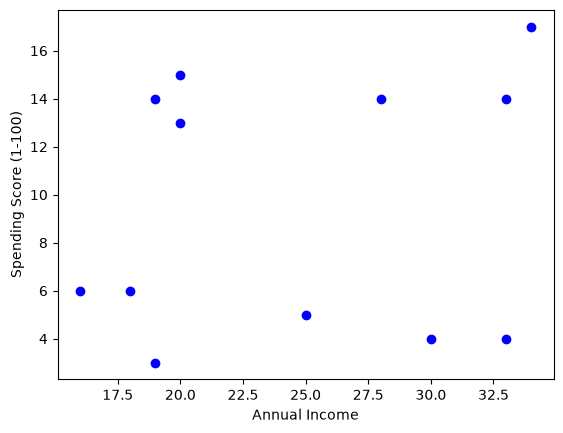

In [42]:
# create 
plt.scatter(df1["Annual Income (k$)"],df1["Spending Score (1-100)"], color="blue")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score (1-100)")
# plt.legend()
plt.show()

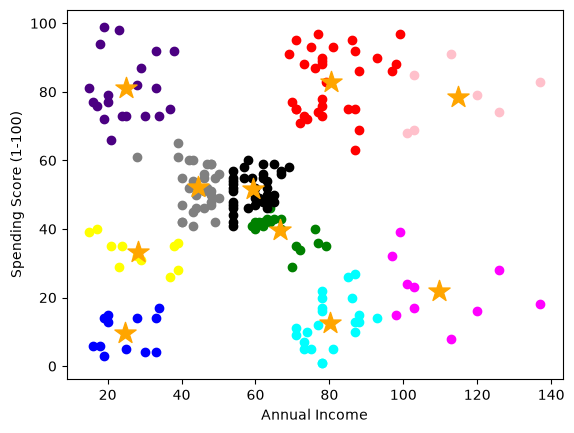

In [68]:
# create 
plt.scatter(df1["Annual Income (k$)"],df1["Spending Score (1-100)"], color="blue")
plt.scatter(df2["Annual Income (k$)"],df2["Spending Score (1-100)"], color="red")
plt.scatter(df3["Annual Income (k$)"],df3["Spending Score (1-100)"], color="green")
plt.scatter(df4["Annual Income (k$)"],df4["Spending Score (1-100)"], color="indigo")
plt.scatter(df5["Annual Income (k$)"],df5["Spending Score (1-100)"], color="cyan")
plt.scatter(df6["Annual Income (k$)"],df6["Spending Score (1-100)"], color="yellow")
plt.scatter(df7["Annual Income (k$)"],df7["Spending Score (1-100)"], color="black")
plt.scatter(df8["Annual Income (k$)"],df8["Spending Score (1-100)"], color="magenta")
plt.scatter(df9["Annual Income (k$)"],df9["Spending Score (1-100)"], color="pink")
plt.scatter(df10["Annual Income (k$)"],df10["Spending Score (1-100)"], color="gray")
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],color="orange", marker="*" , s=255.5)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score (1-100)")
# plt.legend()
plt.show()

#### **Using 7 Clusters**

In [70]:
df = pd.read_csv("data/Mall_Customers.csv")

In [71]:
km = KMeans(n_clusters=7, n_init=10, random_state=42) # instance  of the model
y_hat = km.fit(X)# fit the model

In [72]:
df["cluster"] = km.labels_

In [73]:
df1 = df[df["cluster"] == 0]
df2 = df[df["cluster"] == 1]
df3 = df[df["cluster"] == 2]
df4 = df[df["cluster"] == 3]
df5 = df[df["cluster"] == 4]
df6 = df[df["cluster"] == 5]
df7 = df[df["cluster"] == 6]
df8 = df[df["cluster"] == 7]

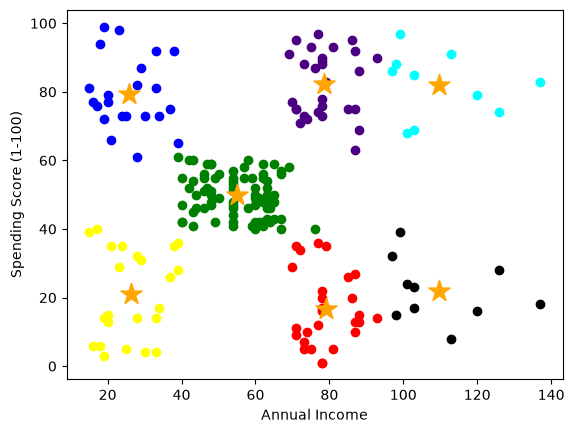

In [74]:
# create 
plt.scatter(df1["Annual Income (k$)"],df1["Spending Score (1-100)"], color="blue")
plt.scatter(df2["Annual Income (k$)"],df2["Spending Score (1-100)"], color="red")
plt.scatter(df3["Annual Income (k$)"],df3["Spending Score (1-100)"], color="green")
plt.scatter(df4["Annual Income (k$)"],df4["Spending Score (1-100)"], color="indigo")
plt.scatter(df5["Annual Income (k$)"],df5["Spending Score (1-100)"], color="cyan")
plt.scatter(df6["Annual Income (k$)"],df6["Spending Score (1-100)"], color="yellow")
plt.scatter(df7["Annual Income (k$)"],df7["Spending Score (1-100)"], color="black")
plt.scatter(df8["Annual Income (k$)"],df8["Spending Score (1-100)"], color="magenta") 
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],color="orange", marker="*" , s=255.5)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score (1-100)")
# plt.legend()
plt.show()

#### **Using 2 Clusters**

In [75]:
df = pd.read_csv("data/Mall_Customers.csv")

In [76]:
km = KMeans(n_clusters=2, n_init=10, random_state=42) # instance  of the model
y_hat = km.fit(X)# fit the model

In [77]:
df["cluster"] = km.labels_

In [78]:
df1 = df[df["cluster"] == 0]
df2 = df[df["cluster"] == 1]

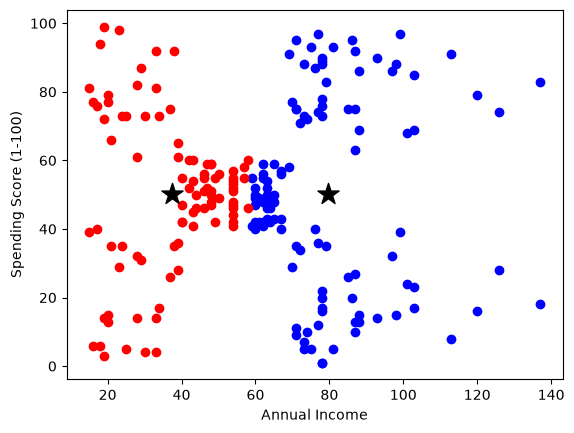

In [79]:
# create 
plt.scatter(df1["Annual Income (k$)"],df1["Spending Score (1-100)"], color="blue")
plt.scatter(df2["Annual Income (k$)"],df2["Spending Score (1-100)"], color="red") 
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],color="black", marker="*" , s=255.5)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score (1-100)")
# plt.legend()
plt.show()

#### **Data Evaluation**

In [86]:
inertias, sils = [], []

cluster_size = range(2, 50)

for k in cluster_size:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

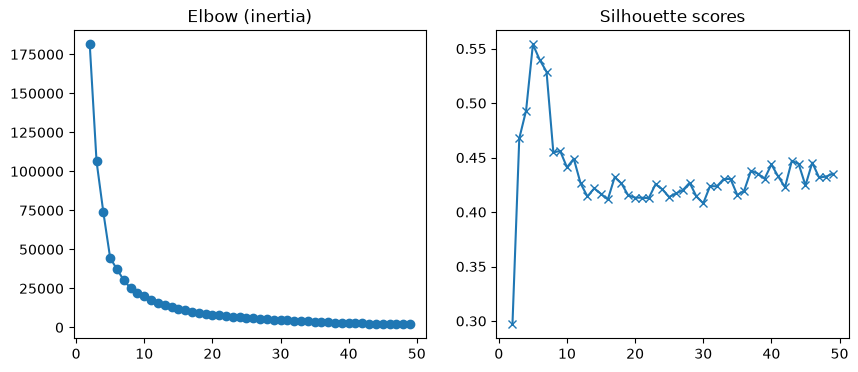

In [87]:
fig, ax = plt.subplots(1,2, figsize=(10, 4))
ax[0].plot(cluster_size, inertias, marker="o"); ax[0].set_title("Elbow (inertia)")
ax[1].plot(cluster_size, sils, marker="x"); ax[1].set_title("Silhouette scores")
plt.show()

In [88]:
inertia, sils = [], []

cluster_size = range(2, 200)

for k in cluster_size:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertia.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

/home/josephridge/Documents/@software-engineering/@datascience/@emobilis/@dataScience-MAY/ML-Series/env/lib/python3.13/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (196) found smaller than n_clusters (197). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/josephridge/Documents/@software-engineering/@datascience/@emobilis/@dataScience-MAY/ML-Series/env/lib/python3.13/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (196) found smaller than n_clusters (198). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/josephridge/Documents/@software-engineering/@datascience/@emobilis/@dataScience-MAY/ML-Series/env/lib/python3.13/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (196) found smaller than n_clusters (199). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


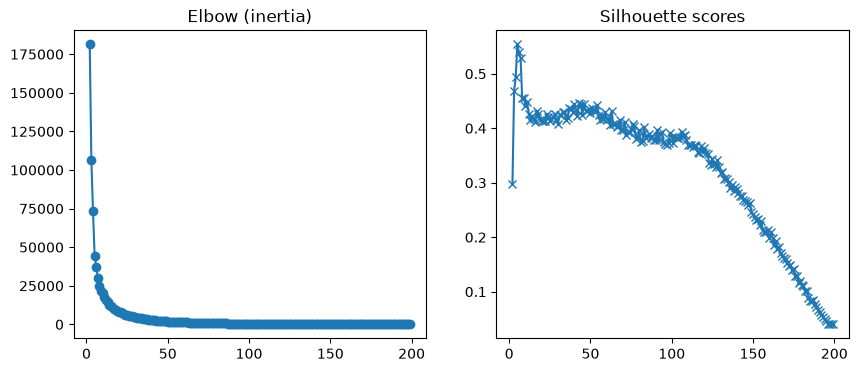

In [90]:
fig, ax = plt.subplots(1,2, figsize=(10, 4))
ax[0].plot(cluster_size, inertia, marker="o"); ax[0].set_title("Elbow (inertia)")
ax[1].plot(cluster_size, sils, marker="x"); ax[1].set_title("Silhouette scores")
plt.show()

In [91]:
inertias, sils = [], []

cluster_size = range(2, 10)

for k in cluster_size:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

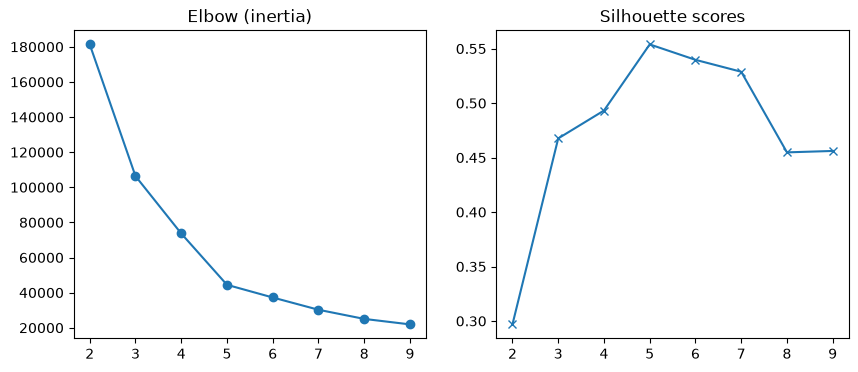

In [92]:
fig, ax = plt.subplots(1,2, figsize=(10, 4))
ax[0].plot(cluster_size, inertias, marker="o"); ax[0].set_title("Elbow (inertia)")
ax[1].plot(cluster_size, sils, marker="x"); ax[1].set_title("Silhouette scores")
plt.show()

The ideal number of clusters is 5 hence the model below

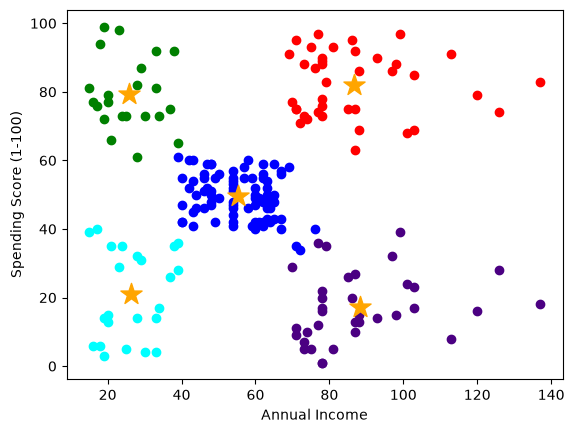

In [95]:
df = pd.read_csv("data/Mall_Customers.csv")
km = KMeans(n_clusters=5, n_init=10, random_state=42) # instance  of the model
y_hat = km.fit(X)# fit the model
df["cluster"] = km.labels_
df1 = df[df["cluster"] == 0]
df2 = df[df["cluster"] == 1]
df3 = df[df["cluster"] == 2]
df4 = df[df["cluster"] == 3]
df5 = df[df["cluster"] == 4]
# create 
plt.scatter(df1["Annual Income (k$)"],df1["Spending Score (1-100)"], color="blue")
plt.scatter(df2["Annual Income (k$)"],df2["Spending Score (1-100)"], color="red")
plt.scatter(df3["Annual Income (k$)"],df3["Spending Score (1-100)"], color="green")
plt.scatter(df4["Annual Income (k$)"],df4["Spending Score (1-100)"], color="indigo")
plt.scatter(df5["Annual Income (k$)"],df5["Spending Score (1-100)"], color="cyan")
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],color="orange", marker="*" , s=255.5)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score (1-100)")
# plt.legend()
plt.show()